In [1]:
import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import nibabel as nib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
import random
from tensorflow.keras import backend as K

#import wandb

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-07 00:41:45.699045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-07 00:41:46.475607: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-07 00:41:46.683196: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-07 00:41:48.270915: I tensorflow/core/platform

In [2]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


I0000 00:00:1762486937.113316  950432 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1762486937.118933  950432 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1762486937.118973  950432 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [ ]:
# FUNÇÕES

# Função para carregar imagens NIfTI, seus rótulos e cortar as imagens
def load_nifti_paths(base_dir, class_names):
    image_paths = []
    labels = []
    
    # Caminhos das subpastas
    for label in class_names:
        label_dir = os.path.join(base_dir, label)
        for fname in os.listdir(label_dir):
            img_path = os.path.join(label_dir, fname)
            image_paths.append(img_path)
            labels.append(label)

    # Codificando os rótulos
    label_encoder = LabelEncoder()

    # Inverter a ordem das classes explicitamente
    label_encoder.classes_ = np.array(class_names)

    # Convertendo a lista de rótulos para um array NumPy
    labels_array = np.array(labels)

    # Codificando os rótulos (agora 'cn' será 0 e 'ad' será 1)
    labels_encoded = label_encoder.transform(labels_array)

    # Transformando os rótulos para one-hot encoding
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Embaralhar os dados
    image_paths, labels_one_hot = shuffle(image_paths, labels_one_hot, random_state=42)

    return image_paths, labels_one_hot, label_encoder.classes_

def load_nifti_data_balanced(base_dir, class_names, target=1000):
    images = []
    labels = []
    paths = []
    
    # Caminhos das subpastas
    for label in class_names:
        print(f"carregando diretório {label}")
        label_dir = os.path.join(base_dir, label)
        count = 0

        names = os.listdir(label_dir)
        #np.random.shuffle(names)
        for fname in names:
            #if count < target:
            img_path = os.path.join(label_dir, fname)
            img = nib.load(img_path).get_fdata(dtype=np.float16)
            paths.append(img_path)
            images.append(img)
            labels.append(label)
            count += 1

        print(f"diretório carregado {count}")

    # Codificando os rótulos
    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)
    labels_encoded = label_encoder.transform(labels)
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Convertendo para arrays NumPy
    images = np.array(images).reshape((-1, *images[0].shape, 1))
    labels_one_hot = np.array(labels_one_hot)
    
    # Embaralhar os dados
    images, labels_one_hot, paths = shuffle(images, labels_one_hot, paths, random_state=42)
    
    return images, labels_one_hot, paths, label_encoder.classes_

def load_nifti_data_balanced_preallocated(base_dir, class_names, augment=False, target_per_class=1000):
    
    available_transforms = [
        tio.RandomBlur(p=1.0),
        tio.RandomNoise(p=1.0, std=(0, 0.05)),
        tio.RandomAnisotropy(p=1.0),
        # tio.RandomElasticDeformation(p=1.0),
        tio.RandomBiasField(p=1.0),
        tio.RandomMotion(p=1.0),
        # tio.RandomSpike(p=1.0),
        tio.RandomGhosting(p=1.0),
    ]

    all_paths = []
    all_labels = []
    print("Passo 1: Coletando lista de arquivos...")
    for label in class_names:
        label_dir = os.path.join(base_dir, label)
        count = 0
        names = os.listdir(label_dir)
        for fname in names:
            if count < target_per_class:
                all_paths.append(os.path.join(label_dir, fname))
                all_labels.append(label)
                count += 1
    print(f"Total de {len(all_paths)} imagens encontradas.")

    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)
    labels_encoded = label_encoder.transform(all_labels)
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names)).astype(np.float16) 
    
    all_paths_shuffled, labels_one_hot_shuffled = shuffle(all_paths, labels_one_hot, random_state=42)
    
    del all_labels, labels_encoded, labels_one_hot
    gc.collect()

    if not all_paths_shuffled:
        print("Nenhuma imagem encontrada.")
        return np.array([]), np.array([]), [], label_encoder.classes_

    print("Passo 2: Determinando o shape da imagem...")
    try:
        first_img_nib = nib.load(all_paths_shuffled[0])
        img_shape = first_img_nib.get_fdata(dtype=np.float16).shape
    except Exception as e:
        print(f"Erro ao carregar a primeira imagem: {e}")
        return

    total_images = len(all_paths_shuffled)
    print(f"Shape detectado: {img_shape}. Alocando memória para {total_images} imagens...")
    
    images_final = np.empty((total_images, *img_shape, 1), dtype=np.float16)
    paths_final = [None] * total_images

    print("Passo 3: Carregando e transformando imagens...")
    for i in range(total_images):
        img_path = all_paths_shuffled[i]
        try:
            img_nib = nib.load(img_path)
            img_data_f16 = img_nib.get_fdata(dtype=np.float16)
            
            if augment:
                # Seleciona aleatoriamente de 1 a 6 transformações do pool
                num_transforms = random.randint(1, 6)
                selected_transforms = random.sample(available_transforms, num_transforms)
                transform_composer = tio.Compose(selected_transforms)

                img_data_f32 = img_data_f16.astype(np.float32)
                subject = tio.Subject(
                    mri=tio.ScalarImage(tensor=img_data_f32[np.newaxis, ...], affine=img_nib.affine)
                )
                # Aplica a composição
                transformed_data_f32 = transform_composer(subject).mri.data.numpy().squeeze(axis=0)
                img_final = transformed_data_f32.astype(np.float16)
                
                del img_data_f32, subject, transformed_data_f32, transform_composer, selected_transforms
            else:
                img_final = img_data_f16
            
            images_final[i] = img_final.reshape((*img_shape, 1))
            paths_final[i] = img_path

        except Exception as e:
            print(f"Erro em {img_path}: {e}. Inserindo array vazio.")
            images_final[i] = np.zeros((*img_shape, 1), dtype=np.float16)
            paths_final[i] = img_path
        
        if (i + 1) % 50 == 0:
            gc.collect()
            print(f"Processado {i + 1}/{total_images}...")
            
    print("Passo 4: Carregamento concluído.")
    return images_final, labels_one_hot_shuffled, paths_final, label_encoder.classes_

def nifti_data_generator_3d(images_array, labels, batch_size):
    total_n = len(images_array)
    
    while True:
        for i in range(0, total_n, batch_size):
            final = min(i + batch_size, total_n)
            batch_images = np.array(images_array[i: final])
            batch_labels = np.array(labels[i:final])

            # Liberar memória
            gc.collect()
            
            yield batch_images, batch_labels

# Função para carregar imagens NIfTI, seus rótulos e cortar as imagens
def nifti_data_generator_3d_path(image_paths, labels, batch_size, size):
    cache_size = batch_size*size
    while True:
        for i in range(0, len(image_paths), cache_size):
            final = min(i + cache_size, len(image_paths))
            batch_paths = image_paths[i:final]
            batch_labels = labels[i:final]
            images = []

            for path in batch_paths:
                # Carregar a imagem NIfTI e garantir o formato correto
                img = nib.load(path).get_fdata(dtype=np.float16)  # Shape original: 
                img = img[..., np.newaxis]       # Adicionar a dimensão do canal: 
                images.append(img)
            
            # Converter lista para array NumPy e garantir o shape correto
            images = np.array(images) 
            batch_labels = np.array(batch_labels)

            # Liberar memória
            gc.collect()
            
            yield images, batch_labels

# realizar predições e armazenar em um vetor
def get_predictions(images, labels, batch_size, best_model):
    pred = []

    for i in range(0, len(images), batch_size):
        final = min(i + batch_size, len(images))
        
        # Fazendo predição para o lote atual
        batch_pred = best_model.predict(images[i:final])
        pred.append(batch_pred)

    # Concatenando as predições e os rótulos verdadeiros
    pred = np.concatenate(pred)

    # Convertendo as predições para rótulos (a classe com maior probabilidade)
    true_labels = np.argmax(labels, axis=1)
    pred_labels = np.argmax(pred, axis=1)
    return pred_labels, true_labels, pred

def plot_training_history(history, dir):
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['categorical_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.savefig(os.path.join(dir, 'training_history.png'))

    plt.show()

def plot_confusion_matrix(y_true, y_pred, dir, subset, class_names):
    # Calcular a matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    # Plotando a matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,  annot_kws={"size": 14})
    plt.xlabel('Previsões')
    plt.ylabel('Valores Reais')
    plt.title(f'Matriz de Confusão - {subset}')
    plt.savefig(f'{dir}/{subset}_confusion_matrix.png')
    plt.show()

def get_classification_report(y_true, y_pred, dir, subset):
    # Gerar relatório
    report = classification_report(y_true, y_pred)
    print(report)

    # Escrevendo o relatório em um arquivo .txt
    with open(os.path.join(dir, f"{subset}_classification_report.txt"), "w") as file:
        file.write(report)

# Função para carregar uma imagem NIfTI e extrair uma fatia específica do eixo Z
def load_nifti_image_pdf(file_path):
    img = nib.load(file_path) 
    data = img.get_fdata(dtype=np.float16)  
    slice_2d = data[2, :, :]
    return slice_2d

# Função para criar o PDF
def create_pdf(y_paths, y_images, y_true_labels, y_pred_labels, y_pred, output_pdf_path, class_names):
    c = canvas.Canvas(output_pdf_path, pagesize=letter)
    width, height = letter  # Dimensões da página no PDF

    #for image, name in zip(y_images, y_paths):
    for i in range(0, len(y_images)):
        true = ''
        pred = ''
        # Carregar a imagem NIfTI e obter a fatia 2D no eixo Z
        # nifti_image = load_nifti_image_pdf(item)
        nifti_image = y_images[i][:, :, 88, 0]

        # Converter a fatia 2D para uma imagem 8-bit (grayscale) para visualização
        img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
        img = img.convert("RGB")  # Garantir que a imagem tenha 3 canais (RGB)

        # Redimensionar a imagem para se ajustar ao tamanho da página
        img_width, img_height = img.size
        aspect_ratio = img_height / float(img_width)
        new_width = width * 0.2  # Definir largura como 80% da largura da página
        new_height = new_width * aspect_ratio
        img = img.resize((int(new_width), int(new_height)))

        # Criar um arquivo temporário para salvar a imagem
        with tempfile.NamedTemporaryFile(delete=False, suffix=".png") as temp_file:
            temp_file_path = temp_file.name
            img.save(temp_file_path)

        # configurar para printar as 7 fatias em uma página inteira, com as informações de label predito e esperado

        # Colocar a imagem no PDF usando o caminho temporário
        if i % 12 < 4:
            x = 80
        elif i % 12 < 8:
            x = width - 2.35*new_width - 80
        else:
            x = width - new_width - 80

        y = height - (new_height + 80)*((i%4)+1)

        c.drawImage(temp_file_path, x, y, width=new_width, height=new_height)

        # Escrever os rótulos
        true_label = y_true_labels[i]
        pred_label = y_pred_labels[i]

        #ver como transformar os labels de maneira inteligente
        true = class_names[true_label]
        pred = class_names[pred_label]

        # Definir a cor para os rótulos
        if true_label == pred_label:
            pred_color = (0, 1, 0)  # Verde
        else:
            pred_color = (1, 0, 0)  # Vermelho
        
        #Nome paciente (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+24, y+new_height+50, f"{os.path.basename(y_paths[i])}")

        # Rótulo esperado (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+26, y+new_height+35, f"Expected: {true}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+20, f"Predicted: {pred}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+5, f"Prob: {max(y_pred[i])*100:.2f}%")

        # Avançar para a próxima imagem
        i += 1
        
        # Adicionar uma nova página no PDF a cada 2 imagens (se necessário)
        if i % 12 == 0:  # Por exemplo, a cada 2 imagens, adicionamos uma nova página
            c.showPage()

    # Salvar o PDF
    c.save()

def plot_custom_confusion_matrix(cm, y_labels, x_labels, dir, subset):
    plt.figure(figsize=(10, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=x_labels, yticklabels=y_labels, 
                annot_kws={"size": 14})
    plt.xlabel('Previsões')
    plt.ylabel('Valores Reais')
    plt.title(f'Matriz de Confusão - {subset}')
    plt.savefig(f'{dir}/{subset}_custom_confusion_matrix.png', bbox_inches='tight')
    plt.show()

def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # # Camada 4
    # x = layers.Conv3D(32, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    # x = layers.BatchNormalization()(x)
    # x = layers.LeakyReLU(negative_slope=0.3)(x)
    # # x = layers.MaxPooling3D(pool_size=(2, 2, 2), padding='same')(x)
    # x = layers.Dropout(0.3)(x)

    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [4]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

train_dir = f'{dir_base}/ADNI/NIFTI_PROCESSED/train'
val_dir = f'{dir_base}/ADNI/NIFTI_PROCESSED/validation'
test_dir = f'{dir_base}/ADNI/NIFTI_PROCESSED/test'

oasis_dir = f'{dir_base}/OASIS/OASIS_2_PROCESSED'

results_dir_base = f'{dir_base}/ADNI/NIFTI_PROCESSED/results/ruidos'
os.makedirs(results_dir_base, exist_ok=True)

transformations = ['blur', 'noise', 'anisotropy', 'elastic', 'bias_field', 'motion', 'spike', 'ghosting']

In [5]:
transform_name = None

for item in transformations:
    results_dir = f"{results_dir_base}/test_{item}"
    if (not os.path.exists(results_dir)) or ((os.path.exists(results_dir) and len(os.listdir(results_dir)) < 3)):
        os.makedirs(results_dir, exist_ok=True)
        print(f"pasta test_{item} criada")
        transform_name = item
        break

pasta test_noise criada


In [7]:
# Nome das classes
adni_class_names = ['cn', 'emci', 'mci', 'lmci', 'ad']
oasis_class_names = ['0.0', '0.5', '1.0']

n_adni_classes = len(adni_class_names)

train_images, train_labels, train_paths, class_labels = load_nifti_data_balanced_preallocated(
    train_dir, 
    adni_class_names, 
    augment=True
)

print(f"N treino: {len(train_paths)}")

Passo 1: Coletando lista de arquivos...
Total de 2648 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (160, 189, 157). Alocando memória para 2648 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/2648...
Processado 100/2648...
Processado 150/2648...
Processado 200/2648...
Processado 250/2648...
Processado 300/2648...
Processado 350/2648...
Processado 400/2648...
Processado 450/2648...
Processado 500/2648...
Processado 550/2648...
Processado 600/2648...
Processado 650/2648...
Processado 700/2648...
Processado 750/2648...
Processado 800/2648...
Processado 850/2648...
Processado 900/2648...
Processado 950/2648...
Processado 1000/2648...
Processado 1050/2648...
Processado 1100/2648...
Processado 1150/2648...
Processado 1200/2648...
Processado 1250/2648...
Processado 1300/2648...
Processado 1350/2648...
Processado 1400/2648...
Processado 1450/2648...
Processado 1500/2648...
Processado 1550/2648...
Processado 1600/2648...
Processado 1650

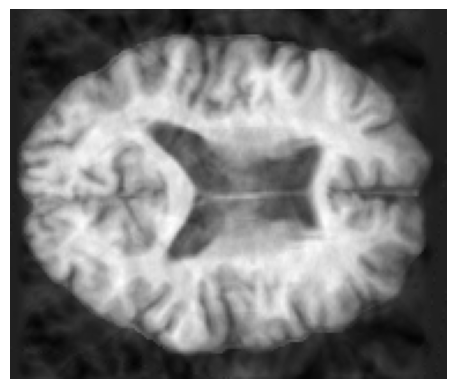

In [8]:
plt.imshow(train_images[0][:, :, 88], cmap='grey')
plt.axis('off')
plt.show()

In [9]:
val_images, val_labels, val_paths, _ = load_nifti_data_balanced_preallocated(
    val_dir, 
    adni_class_names, 
    augment=True
)

print(f"N validation: {len(val_paths)}")

Passo 1: Coletando lista de arquivos...
Total de 719 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (160, 189, 157). Alocando memória para 719 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/719...
Processado 100/719...
Processado 150/719...
Processado 200/719...
Processado 250/719...
Processado 300/719...
Processado 350/719...
Processado 400/719...
Processado 450/719...
Processado 500/719...
Processado 550/719...
Processado 600/719...
Processado 650/719...
Processado 700/719...
Passo 4: Carregamento concluído.
N validation: 719


In [10]:
# Compila model
model = create_model_3d(train_images[0].shape, n_adni_classes)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model.summary()

I0000 00:00:1762490233.078031  950432 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1762490233.078101  950432 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1762490233.078121  950432 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1762490233.361482  950432 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1762490233.361536  950432 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-11-07

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 189, 157,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 160, 189, 157,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 189, 157,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 160, 189, 157,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 54, 63, 53, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 63, 53, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 54, 63, 53, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 63, 53, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 54, 63, 53, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 18, 21, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 21, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 18, 21, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 21, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 18, 21, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 6, 7, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 7, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4032)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        64,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             

 Total params: 69,245 (270.49 KB)

 Trainable params: 69,157 (270.14 KB)

 Non-trainable params: 88 (352.00 B)

In [11]:
batch_size = 64

steps_per_epoch = len(train_paths) // batch_size
validation_steps = len(val_paths) // batch_size

train_generator = nifti_data_generator_3d(train_images, train_labels, batch_size)
val_generator = nifti_data_generator_3d(val_images, val_labels, batch_size)

epochs = 200

new_model_name_ker = (f"binary_classifier_noise_{epochs}_epochs_batch_{batch_size}_{n_adni_classes}_classes.keras")

# Parar caso fique {patience} épocas sem melhora
early_stopping = EarlyStopping(
    monitor='val_loss',     
    patience=30,                 
    verbose=1
)

# # Defina o nome do arquivo para salvar o melhor modelo
model_checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(results_dir, new_model_name_ker),    
    monitor='val_categorical_accuracy',
    save_best_only=True, 
    mode='max', 
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

log_path = os.path.join(results_dir, 'log_treino_ruido.csv')

csv_log = CSVLogger(log_path, append=False)

In [12]:
print(f"Iniciando treinamento do modelo {new_model_name_ker} para classes {adni_class_names}")

# Treinamento
history = model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[model_checkpoint_callback, reduce_lr, csv_log, early_stopping]
)

Iniciando treinamento do modelo binary_classifier_noise_200_epochs_batch_64_5_classes.keras para classes ['cn', 'emci', 'mci', 'lmci', 'ad']
Epoch 1/200


I0000 00:00:1762490238.813890 1245872 service.cc:146] XLA service 0x7fd240009390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762490238.813935 1245872 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-11-07 01:37:19.100485: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-07 01:37:19.742019: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2025-11-07 01:37:25.218842: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-07 01:37:25.218925: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Al

41/41 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - categorical_accuracy: 0.2226 - loss: 2.3974 - val_categorical_accuracy: 0.2088 - val_loss: 2.0776 - learning_rate: 5.0000e-04
Epoch 2/200


2025-11-07 01:38:48.078758: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.1133 = f32[24,18,21,18,8]{4,3,2,1,0} reduce-window(f32[24,54,63,53,8]{4,3,2,1,0} %broadcast.1121, f32[] %constant.1122), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x0_0x0_0x0_1x0_0}, to_apply=%region_1.1129, metadata={op_type="AvgPool3D" op_name="functional_1/average_pooling3d_1_2/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-11-07 01:38:50.644800: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 3.566061307s
Constant folding an inst

41/41 ━━━━━━━━━━━━━━━━━━━━ 163s 997ms/step - categorical_accuracy: 0.2492 - loss: 2.1950 - val_categorical_accuracy: 0.1918 - val_loss: 2.0627 - learning_rate: 5.0000e-04
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - categorical_accuracy: 0.2704 - loss: 2.0885

2025-11-07 01:42:08.788044: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %reduce-window.194 = f32[15,18,21,18,8]{4,3,2,1,0} reduce-window(f32[15,54,63,53,8]{4,3,2,1,0} %broadcast.182, f32[] %constant.183), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x0_0x0_0x0_1x0_0}, to_apply=%region_1.190, metadata={op_type="AvgPool3D" op_name="functional_1/average_pooling3d_1_2/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-11-07 01:42:09.053009: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 2.26499962s
Constant folding an instructi

41/41 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - categorical_accuracy: 0.2728 - loss: 2.0759 - val_categorical_accuracy: 0.2061 - val_loss: 2.0163 - learning_rate: 5.0000e-04
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 992ms/step - categorical_accuracy: 0.2976 - loss: 1.9951 - val_categorical_accuracy: 0.2000 - val_loss: 2.0065 - learning_rate: 5.0000e-04
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - categorical_accuracy: 0.3150 - loss: 1.9435 - val_categorical_accuracy: 0.2107 - val_loss: 1.9961 - learning_rate: 5.0000e-04
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 996ms/step - categorical_accuracy: 0.3305 - loss: 1.8966 - val_categorical_accuracy: 0.3023 - val_loss: 1.9542 - learning_rate: 5.0000e-04
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - categorical_accuracy: 0.3467 - loss: 1.8297 - val_categorical_accuracy: 0.3145 - val_loss: 1.9381 - learning_rate: 5.0000e-04
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - categorical_accuracy: 0.3491 - loss: 1.7864 - val_categori

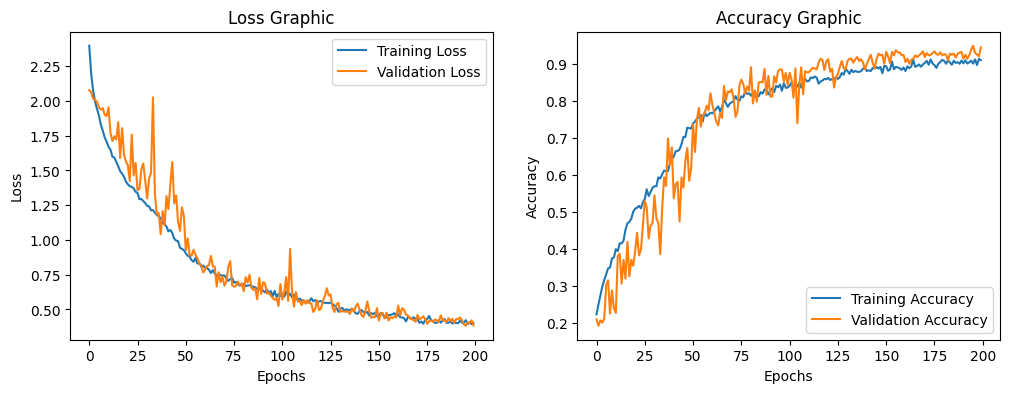

In [13]:
# Plotando o histórico de treinamento após o treinamento
plot_training_history(history, results_dir)

### PREDIÇÃO TREINO

In [18]:
def generate_pdf_report_safe(model, images, true_labels_onehot, class_names, output_path, max_samples=None):
    """
    Gera um PDF com plots, prevendo UMA imagem de cada vez para economizar RAM.
    
    Args:
        model: Modelo treinado.
        images: Array numpy com as imagens 3D (N, D, H, W, C).
        true_labels_onehot: Labels reais em one-hot (N, n_classes).
        class_names: Lista com nomes das classes.
        output_path: Caminho para salvar o PDF.
        max_samples: Limite opcional de amostras para plotar (None para todas).
    """
    
    # Decodifica os labels verdadeiros uma vez
    true_indices = np.argmax(true_labels_onehot, axis=1)
    
    n_samples = len(images)
    if max_samples is not None and max_samples < n_samples:
        n_samples = max_samples
        print(f"Limitando relatório a {n_samples} amostras.")

    print(f"Gerando PDF em: {output_path} (modo de baixo uso de memória)")
    
    # Abre o arquivo PDF
    with PdfPages(output_path) as pdf:
        for i in range(n_samples):
            # Pega o volume e o label verdadeiro
            vol = images[i]
            true_index = true_indices[i]
            true_label = class_names[true_index]

            # --- MODIFICAÇÃO PRINCIPAL ---
            # 1. Adiciona a dimensão do batch (1, D, H, W, C)
            vol_batch = np.expand_dims(vol, axis=0) 
            
            # 2. Faz a predição APENAS para esta imagem
            #    O verbose=0 evita poluir o console
            pred_probs_single = model.predict(vol_batch, verbose=0)
            
            # 3. Processa a predição (remove a dimensão do batch [0])
            pred_index = np.argmax(pred_probs_single[0])
            pred_label = class_names[pred_index]
            confidence = pred_probs_single[0][pred_index] * 100
            # --- FIM DA MODIFICAÇÃO ---

            # Extrai fatia central
            mid_slice_idx = vol.shape[0] // 2  
            img_slice = vol[:, :, mid_slice_idx, 0] # Fatia central

            # Define status e cor
            is_correct = true_index == pred_index
            title_color = 'green' if is_correct else 'red'
            status = "CORRETO" if is_correct else "ERRO"

            # Cria o plot
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.imshow(img_slice, cmap='gray')
            ax.axis('off')
            
            title_text = (f"Amostra {i} [{status}]\n"
                          f"Real: {true_label} | Pred: {pred_label}\n"
                          f"Confiança: {confidence:.2f}%")
            
            ax.set_title(title_text, color=title_color, fontsize=10)
            
            # Salva a figura no PDF
            pdf.savefig(fig)
            plt.close(fig) # Essencial para liberar memória do plot

            if (i + 1) % 50 == 0:
                print(f"Processado {i + 1}/{n_samples} plots...")

    print("Relatório PDF concluído.")

pdf_path = os.path.join(results_dir, f"relatorio_treino_{new_model_name_ker}.pdf")
# Use a nova função "safe"
generate_pdf_report_safe( 
    model=model,
    images=train_images,
    true_labels_onehot=train_labels,
    class_names=adni_class_names,
    output_path=pdf_path,
    max_samples=500
)

Limitando relatório a 500 amostras.
Gerando PDF em: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/NIFTI_PROCESSED/results/ruidos/test_noise/relatorio_treino_binary_classifier_noise_200_epochs_batch_64_5_classes.keras.pdf (modo de baixo uso de memória)
Processado 50/500 plots...
Processado 100/500 plots...
Processado 150/500 plots...
Processado 200/500 plots...
Processado 250/500 plots...
Processado 300/500 plots...
Processado 350/500 plots...
Processado 400/500 plots...
Processado 450/500 plots...
Processado 500/500 plots...
Relatório PDF concluído.


### PREDIÇÃO VALIDAÇÃO

2025-11-07 10:32:19.428284: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=2,k13=0,k14=3,k18=0,k23=0} for conv (f16[32,4,160,189,157]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[32,1,160,189,157]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-11-07 10:32:20.097663: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.669448667s
Trying algorithm eng10{k2=2,k13=0,k14=3,k18=0,k23=0} for conv (f16[32,4,160,189,157]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[32,1,160,189,157]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, 

2/2 ━━━━━━━━━━━━━━━━━━━━ 52s 231ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       137
           1       0.89      0.96      0.92       130
           2       0.99      0.91      0.95       153
           3       0.97      0.99      0.98       147
           4       0.91      0.95      0.93       152

    accuracy                           0.94       719
   macro avg       0.94      0.94      0.93       719
weighted avg       0.94      0.94      0.94       719



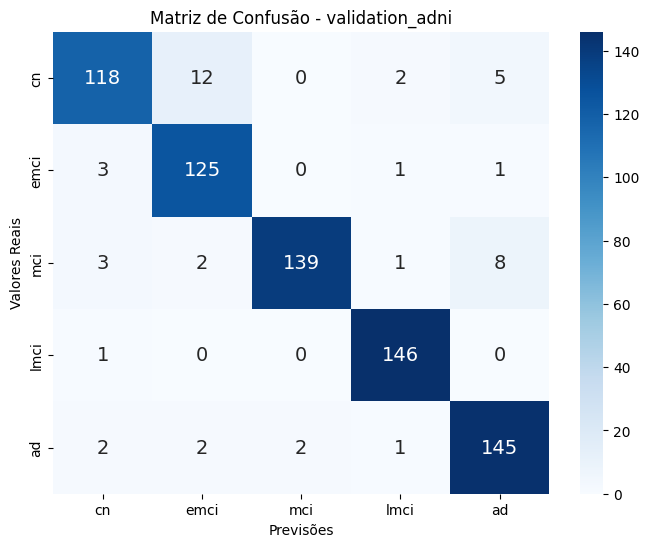

In [15]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = get_predictions(val_images, val_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(val_true_labels, val_pred_labels, results_dir, 'validation_adni')

# Obter matriz de confusão
plot_confusion_matrix(val_true_labels, val_pred_labels, results_dir, 'validation_adni', adni_class_names)

# Criar pdf com predições
val_pdf_path = os.path.join(results_dir, "validation_adni_predictions.pdf")
create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, adni_class_names)

### PREDIÇÃO TESTE

Passo 1: Coletando lista de arquivos...
Total de 371 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (160, 189, 157). Alocando memória para 371 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/371...
Processado 100/371...
Processado 150/371...
Processado 200/371...
Processado 250/371...
Processado 300/371...
Processado 350/371...
Passo 4: Carregamento concluído.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step

2025-11-07 10:36:15.369100: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=1,k13=0,k14=4,k18=0,k23=0} for conv (f16[19,4,160,189,157]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[19,1,160,189,157]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-11-07 10:36:16.141043: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.772117123s
Trying algorithm eng10{k2=1,k13=0,k14=4,k18=0,k23=0} for conv (f16[19,4,160,189,157]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[19,1,160,189,157]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, 

2/2 ━━━━━━━━━━━━━━━━━━━━ 35s 34s/step
              precision    recall  f1-score   support

           0       0.95      0.78      0.86        73
           1       0.85      0.94      0.89        70
           2       0.94      0.88      0.91        77
           3       0.96      1.00      0.98        75
           4       0.92      1.00      0.96        76

    accuracy                           0.92       371
   macro avg       0.92      0.92      0.92       371
weighted avg       0.92      0.92      0.92       371



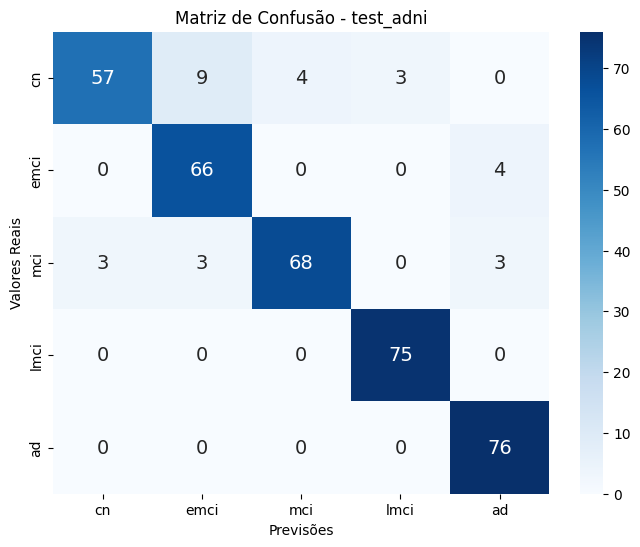

In [16]:
test_images, test_labels, test_paths, _ = load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = get_predictions(test_images, test_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(test_true_labels, test_pred_labels, results_dir, 'test_adni')

# Obter matriz de confusão
plot_confusion_matrix(test_true_labels, test_pred_labels, results_dir, 'test_adni', adni_class_names)

# Criar pdf com predições
test_pdf_path = os.path.join(results_dir, "test_adni_predictions.pdf")
create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, adni_class_names)

### PREDIÇÃO OASIS

Passo 1: Coletando lista de arquivos...
Total de 150 imagens encontradas.
Passo 2: Determinando o shape da imagem...
Shape detectado: (160, 189, 157). Alocando memória para 150 imagens...
Passo 3: Carregando e transformando imagens...
Processado 50/150...
Processado 100/150...
Processado 150/150...
Passo 4: Carregamento concluído.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step


2025-11-07 10:37:32.365545: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=2,k13=0,k14=3,k18=0,k23=0} for conv (f16[22,4,160,189,157]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[22,1,160,189,157]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-11-07 10:37:32.460216: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.104113631s
Trying algorithm eng10{k2=2,k13=0,k14=3,k18=0,k23=0} for conv (f16[22,4,160,189,157]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[22,1,160,189,157]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, 

1/1 ━━━━━━━━━━━━━━━━━━━━ 38s 38s/step
              precision    recall  f1-score   support

           0       0.62      0.41      0.50        85
           1       0.33      0.08      0.12        52
           2       0.11      0.23      0.15        13
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0

    accuracy                           0.28       150
   macro avg       0.21      0.14      0.15       150
weighted avg       0.48      0.28      0.34       150



/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use 

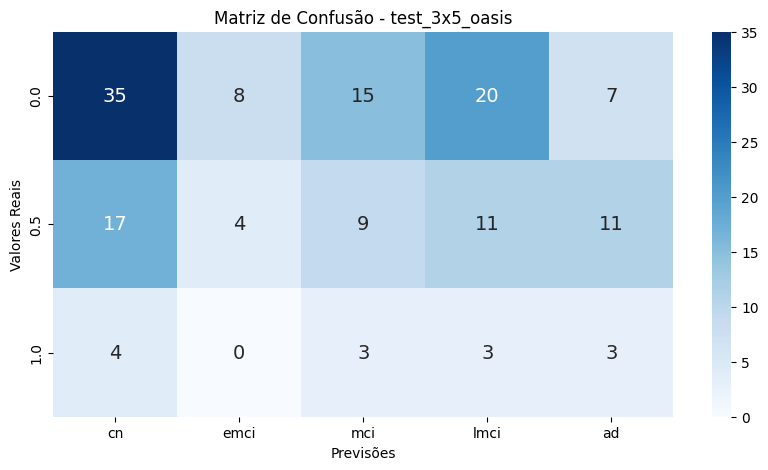

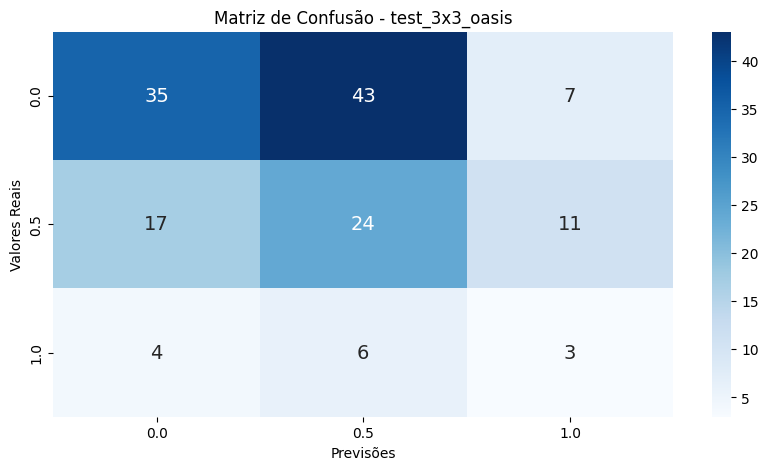

In [17]:
oasis_images, oasis_labels, oasis_paths, _ = load_nifti_data_balanced_preallocated(oasis_dir, oasis_class_names)

# Realizar predições para dados do conjunto validação
oasis_pred_labels, oasis_true_labels, oasis_pred = get_predictions(oasis_images, oasis_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(oasis_true_labels, oasis_pred_labels, results_dir, 'test_oasis')

# Obter matriz de confusão
cm_adjusted = confusion_matrix(oasis_true_labels, oasis_pred_labels)[0:3, :]
plot_custom_confusion_matrix(cm_adjusted, oasis_class_names, adni_class_names, results_dir, 'test_3x5_oasis')

gathered_oasis_pred = []

for i in range(len(oasis_pred_labels)):
    if oasis_pred_labels[i] == 0:
        gathered_oasis_pred.append(0)
    elif oasis_pred_labels[i] < 4 and oasis_pred_labels[i] > 0:
        gathered_oasis_pred.append(1)
    elif oasis_pred_labels[i] == 4:
        gathered_oasis_pred.append(2)

# all_possible_numeric_labels = [0.0, 0.5, 1.0, 2.0, 3.0]

cm_3x3_adjusted = confusion_matrix(oasis_true_labels, gathered_oasis_pred)[0:3, 0:3]

# Chame a nova função para plotar a matriz ajustada (3x5)
plot_custom_confusion_matrix(cm_3x3_adjusted, oasis_class_names, oasis_class_names, results_dir, 'test_3x3_oasis')

# Criar pdf com predições
oasis_pdf_path = os.path.join(results_dir, "test_oasis_predictions.pdf")
create_pdf(oasis_paths, oasis_images, oasis_true_labels, gathered_oasis_pred, oasis_pred, oasis_pdf_path, oasis_class_names)